# Fase 3 (v2) — Feature Engineering con Variables Q Ordinales

## Objetivo
Reconstruir el conjunto de features usando las columnas **Q ordinales**
(escala de 3-7 niveles) en lugar de las QN binarias del intento anterior.

## Motivación del cambio
El primer intento con variables QN binarias produjo R² ≈ 0 en regresión IMC,
equivalente a predecir la media. Las QN colapsan la variación de comportamiento
en Sí/No, eliminando la granularidad que necesita el modelo para encontrar señal.

## Estrategia
- **Tarea A (Regresión IMC):** features Q ordinales de alimentación,
  actividad física y comportamientos de riesgo
- **Tarea B (Clasificación Riesgo_SM):** mismo set de features
- Excluir Q4, Q5 (leakage IMC) y Q26/QN26 (leakage salud mental)
- Imputación por mediana (continuas) y moda (ordinales)
- Escalado con RobustScaler

In [2]:
# ============================================================
# FASE 3 (v2) — Feature Engineering con Q ordinales
# Notebook: 03_feature_engineering_v2.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# ── Rutas relativas ancladas al notebook ──────────────────
# Path(__file__) no funciona en notebooks; usamos cwd()
# que apunta a la carpeta notebooks/ donde vive este archivo
NOTEBOOK_DIR = Path.cwd()
ROOT         = NOTEBOOK_DIR.parent
PROCESSED    = ROOT / 'data' / 'processed'
FIGURES      = ROOT / 'reports' / 'figures'
MODELS       = ROOT / 'models'

# Verificar que las rutas existen
for nombre, ruta in [('processed', PROCESSED),
                     ('figures',   FIGURES),
                     ('models',    MODELS)]:
    status = '✓' if ruta.exists() else '✗ NO EXISTE'
    print(f"  {status}  {nombre}: {ruta}")

# Cargar dataset limpio de Fase 2
df = pd.read_csv(PROCESSED / 'slv2013_clean.csv')

print(f"\nDataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(list(df.columns))

  ✓  processed: /Users/jpurquilla/Desktop/UES-ML/Desafio 2/Prediccion-FactoresRiesgo/data/processed
  ✓  figures: /Users/jpurquilla/Desktop/UES-ML/Desafio 2/Prediccion-FactoresRiesgo/reports/figures
  ✓  models: /Users/jpurquilla/Desktop/UES-ML/Desafio 2/Prediccion-FactoresRiesgo/models

Dataset cargado: 1915 filas × 90 columnas

Columnas disponibles (90):
['Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q44', 'Q45', 'Q46', 'Q47', 'Q48', 'Q49', 'Q50', 'Q51', 'Q52', 'Q53', 'Q54', 'Q55', 'Q56', 'Q57', 'Q58', 'QN6', 'QN7', 'QN8', 'QN9', 'QN10', 'QN11', 'QN12', 'QN13', 'QN14', 'QN15', 'QN16', 'QN17', 'QN20', 'QN22', 'QN23', 'QN24', 'QN25', 'QN26', 'QN27', 'QN35', 'QN38', 'QN39', 'QN44', 'QN46', 'QN49', 'QN50', 'QN51', 'QN52', 'QN53', 'QN54', 'QN55', 'QN56', 'QN57', 'QN58', 'qnowtg', 'qnobeseg', 'qnunwtg', 'qnfrvgg', 'qnpa7

## Paso 1 — Clasificar columnas disponibles

Separamos las columnas en tres grupos:
- **Q ordinales:** preguntas originales con múltiples niveles — las usaremos como features
- **QN binarias:** recodificaciones 0/1 de la OPS — las excluimos para evitar colinealidad
- **qn* derivadas:** indicadores compuestos; incluimos solo los que no derivan del IMC

### Exclusiones obligatorias por data leakage
| Columna | Razón |
|---------|-------|
| Q4, Q5 | Estatura y peso — con ellas se calcula IMC directamente |
| Q26, QN26 | Target de Tarea B (salud mental) |
| IMC | Target de Tarea A |
| Riesgo_SM | Target de Tarea B |
| qnowtg, qnobeseg, qnunwtg | Derivadas directamente del IMC |
| weight | Peso muestral, no es feature de comportamiento |

In [3]:
# ── Clasificar columnas por tipo ───────────────────────────

EXCLUIR = [
    'Q4', 'Q5',                        # leakage IMC
    'Q26', 'QN26',                     # leakage Tarea B
    'IMC', 'Riesgo_SM',                # targets
    'qnowtg', 'qnobeseg', 'qnunwtg',   # derivadas de IMC
    'weight',                          # peso muestral
]

# Q ordinales: empiezan con Q pero NO con QN, y no están en EXCLUIR
cols_Q = [c for c in df.columns
          if c.startswith('Q')
          and not c.startswith('QN')
          and c not in EXCLUIR]

# QN binarias: solo para referencia, no entran como features
cols_QN = [c for c in df.columns
           if c.startswith('QN')
           and c not in EXCLUIR]

# Derivadas que SÍ podemos usar (comportamiento, no IMC)
# qnfrvgg = consumo frutas/verduras
# qnpa7g  = actividad física 7 días
# qnpe5g  = sedentarismo (pantalla 5+ horas)
cols_derivadas = ['qnfrvgg', 'qnpa7g', 'qnpe5g']

print(f"Q ordinales disponibles ({len(cols_Q)}):")
print(cols_Q)
print(f"\nQN binarias excluidas ({len(cols_QN)}):")
print(cols_QN)
print(f"\nDerivadas a incluir: {cols_derivadas}")

Q ordinales disponibles (46):
['Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q27', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q44', 'Q45', 'Q46', 'Q47', 'Q48', 'Q49', 'Q50', 'Q51', 'Q52', 'Q53', 'Q54', 'Q55', 'Q56', 'Q57', 'Q58']

QN binarias excluidas (33):
['QN6', 'QN7', 'QN8', 'QN9', 'QN10', 'QN11', 'QN12', 'QN13', 'QN14', 'QN15', 'QN16', 'QN17', 'QN20', 'QN22', 'QN23', 'QN24', 'QN25', 'QN27', 'QN35', 'QN38', 'QN39', 'QN44', 'QN46', 'QN49', 'QN50', 'QN51', 'QN52', 'QN53', 'QN54', 'QN55', 'QN56', 'QN57', 'QN58']

Derivadas a incluir: ['qnfrvgg', 'qnpa7g', 'qnpe5g']


## Paso 2 — Construir el feature set y auditar nulos

Antes de imputar necesitamos saber qué tan incompleta está cada columna.
La regla que aplicamos en Fase 2 fue: **eliminar columnas con >60% nulos**.
Aquí aplicamos la misma regla para no imputar columnas casi vacías.

### Feature set candidato
- 46 columnas Q ordinales (demografía + comportamientos)
- 3 columnas derivadas de comportamiento (frutas, actividad física, sedentarismo)
- **Total candidatas: 49 features**

In [4]:
# ── Construir feature set candidato y auditar nulos ────────

features_candidatas = cols_Q + cols_derivadas

# DataFrame solo con las features candidatas
X_candidato = df[features_candidatas].copy()

# Calcular % de nulos por columna
nulos = (X_candidato.isnull().sum() / len(X_candidato) * 100).sort_values(ascending=False)

print(f"Features candidatas: {len(features_candidatas)}")
print(f"\n% de nulos por columna (solo las que tienen >0%):")
print(nulos[nulos > 0].round(2).to_string())

# Columnas con >60% nulos → candidatas a eliminar
cols_alta_nulidad = nulos[nulos > 60].index.tolist()
print(f"\nColumnas con >60% nulos (a eliminar): {cols_alta_nulidad}")
print(f"Columnas que sobreviven: {len(features_candidatas) - len(cols_alta_nulidad)}")

Features candidatas: 49

% de nulos por columna (solo las que tienen >0%):
Q17        10.50
Q19         9.09
Q34         8.09
Q18         6.06
Q44         5.12
Q20         4.49
Q37         4.18
Q35         4.07
Q48         3.81
Q39         3.39
Q47         2.92
Q21         2.92
Q51         2.77
qnpe5g      2.77
Q36         2.61
Q45         2.56
Q25         2.51
Q56         2.45
Q27         2.25
Q53         2.19
Q3          2.19
Q58         2.04
Q38         1.83
qnfrvgg     1.83
Q46         1.72
Q2          1.67
Q8          1.51
Q55         1.51
Q1          1.51
Q22         1.51
Q52         1.41
Q24         1.31
Q15         1.25
Q12         1.25
Q50         1.20
Q57         1.15
Q11         1.10
Q7          0.78
Q49         0.78
qnpa7g      0.78
Q10         0.73
Q6          0.73
Q14         0.73
Q54         0.57
Q13         0.47
Q9          0.42
Q40         0.37
Q16         0.26
Q23         0.21

Columnas con >60% nulos (a eliminar): []
Columnas que sobreviven: 49


## Paso 3 — Definir targets y feature set final

Con las 49 features validadas, ahora separamos:
- **X** → las 49 features (input del modelo)
- **y_A** → IMC (target Tarea A, regresión)
- **y_B** → Riesgo_SM (target Tarea B, clasificación)

### Nulos máximos por columna: 10.5% (Q17)
Todos manejables con imputación — no se elimina ninguna feature.
La estrategia de imputación será:
- **Q1, Q2, Q3** (demográficas ordinales) → **moda**
- **Resto de Q ordinales y derivadas** → **mediana**
(la mediana es robusta ante la distribución asimétrica de encuestas)

In [5]:
# ── Definir feature set final y targets ───────────────────

# Feature set final: las 49 que sobrevivieron la auditoría
features_final = features_candidatas  # lista de 49 columnas

X = df[features_final].copy()

# Target Tarea A — regresión IMC
y_A = df['IMC'].copy()

# Target Tarea B — clasificación salud mental
y_B = df['Riesgo_SM'].copy()

print(f"X shape:  {X.shape}")
print(f"y_A shape: {y_A.shape}  | nulos: {y_A.isnull().sum()}")
print(f"y_B shape: {y_B.shape}  | nulos: {y_B.isnull().sum()}")

print(f"\nFeatures finales ({len(features_final)}):")
print(features_final)

# Distribución del target B
print(f"\nDistribución Riesgo_SM:")
print(y_B.value_counts())
print(f"Ratio desbalance: {y_B.value_counts()[0]/y_B.value_counts()[1]:.1f}:1")

X shape:  (1915, 49)
y_A shape: (1915,)  | nulos: 177
y_B shape: (1915,)  | nulos: 9

Features finales (49):
['Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q27', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q44', 'Q45', 'Q46', 'Q47', 'Q48', 'Q49', 'Q50', 'Q51', 'Q52', 'Q53', 'Q54', 'Q55', 'Q56', 'Q57', 'Q58', 'qnfrvgg', 'qnpa7g', 'qnpe5g']

Distribución Riesgo_SM:
Riesgo_SM
0.0    1651
1.0     255
Name: count, dtype: int64
Ratio desbalance: 6.5:1


## Paso 4 — Train/Test Split

### ¿Por qué dividir ANTES de imputar?
Si imputáramos primero sobre todo el dataset, la mediana/moda del conjunto
de test "contaminaría" el entrenamiento — el modelo vería indirectamente
información del test. El orden correcto es:

1. **Split** → separar train y test
2. **Fit del imputador** → solo sobre X_train
3. **Transform** → aplicar a X_train y X_test por separado

### Manejo de nulos en targets
- **y_A** tiene 177 nulos → filas sin IMC no pueden entrenar Tarea A
- **y_B** tiene 9 nulos → filas sin Riesgo_SM no pueden entrenar Tarea B
- Solución: eliminar filas con nulo en y_B antes del split (son solo 9)
- Los 177 nulos de y_A se manejan dentro de cada tarea al momento de entrenar

### Parámetros del split
- 80% train / 20% test
- Estratificado por Riesgo_SM (preserva el ratio 6.5:1 en ambos conjuntos)
- random_state=42 para reproducibilidad

In [6]:
# ── Train/Test Split ───────────────────────────────────────

# Eliminar las 9 filas sin valor en y_B (no aportan a ninguna tarea)
mask_validos = y_B.notna()
X_split  = X[mask_validos].copy()
y_A_split = y_A[mask_validos].copy()
y_B_split = y_B[mask_validos].copy()

print(f"Filas eliminadas por nulo en y_B: {(~mask_validos).sum()}")
print(f"Filas útiles para split: {len(X_split)}")

# Split estratificado por Riesgo_SM
X_train, X_test, \
y_A_train, y_A_test, \
y_B_train, y_B_test = train_test_split(
    X_split, y_A_split, y_B_split,
    test_size=0.2,
    random_state=42,
    stratify=y_B_split
)

print(f"\nTrain: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"\nBalance train → Clase 0: {(y_B_train==0).sum()} / Clase 1: {(y_B_train==1).sum()}")
print(f"Balance test  → Clase 0: {(y_B_test==0).sum()}  / Clase 1: {(y_B_test==1).sum()}")
print(f"\nNulos en y_A_train: {y_A_train.isnull().sum()}")
print(f"Nulos en y_A_test:  {y_A_test.isnull().sum()}")

Filas eliminadas por nulo en y_B: 9
Filas útiles para split: 1906

Train: 1524 filas | Test: 382 filas

Balance train → Clase 0: 1320 / Clase 1: 204
Balance test  → Clase 0: 331  / Clase 1: 51

Nulos en y_A_train: 142
Nulos en y_A_test:  35


## Paso 5 — Imputación de nulos en features (X)

### Regla de oro: fit solo en train, transform en ambos
El imputador aprende la mediana/moda **únicamente del train set**.
Luego aplica esos mismos valores al test set.
Esto evita que el test "informe" al modelo sobre sus propios valores.

### Estrategia por tipo de columna
| Columnas | Estrategia | Razón |
|----------|-----------|-------|
| Q1, Q2, Q3 | **moda** | Demográficas categóricas (edad, sexo, grado) |
| Q6…Q58, qn* | **mediana** | Ordinales de comportamiento — robusta ante asimetría |

### ¿Por qué mediana y no media?
Las escalas ordinales de encuesta (ej. 1-5 días) suelen tener
distribuciones asimétricas. La mediana

In [7]:
# ── Imputación de nulos en X ───────────────────────────────

# Separar columnas por estrategia de imputación
cols_moda    = ['Q1', 'Q2', 'Q3']
cols_mediana = [c for c in features_final if c not in cols_moda]

# Imputador por moda (demografía)
imp_moda = SimpleImputer(strategy='most_frequent')
imp_moda.fit(X_train[cols_moda])

# Imputador por mediana (comportamiento)
imp_mediana = SimpleImputer(strategy='median')
imp_mediana.fit(X_train[cols_mediana])

# Aplicar a train
X_train_imp = X_train.copy()
X_train_imp[cols_moda]    = imp_moda.transform(X_train[cols_moda])
X_train_imp[cols_mediana] = imp_mediana.transform(X_train[cols_mediana])

# Aplicar a test (con los mismos imputadores del train)
X_test_imp = X_test.copy()
X_test_imp[cols_moda]    = imp_moda.transform(X_test[cols_moda])
X_test_imp[cols_mediana] = imp_mediana.transform(X_test[cols_mediana])

# Verificar que no queden nulos
print(f"Nulos en X_train tras imputación: {X_train_imp.isnull().sum().sum()}")
print(f"Nulos en X_test  tras imputación: {X_test_imp.isnull().sum().sum()}")
print(f"\nShape X_train: {X_train_imp.shape}")
print(f"Shape X_test:  {X_test_imp.shape}")

Nulos en X_train tras imputación: 0
Nulos en X_test  tras imputación: 0

Shape X_train: (1524, 49)
Shape X_test:  (382, 49)


## Paso 6 — Escalado con RobustScaler

### ¿Por qué escalar?
Los modelos de ML son sensibles a la magnitud de las variables.
Si Q1 (edad) va de 1-7 y Q17 (horas de sueño) va de 1-4, el modelo
podría darle más peso a Q1 simplemente por tener valores más grandes,
no porque sea más importante.

### ¿Por qué RobustScaler y no StandardScaler?
| Scaler | Cómo funciona | Problema |
|--------|--------------|---------|
| StandardScaler | (x - media) / std | Sensible a outliers |
| **RobustScaler** | (x - mediana) / IQR | Resistente a outliers ✓ |

El IMC tiene outliers reales (obesidad severa). RobustScaler usa la
mediana y el rango intercuartílico (IQR) en lugar de media y desviación
estándar, por lo que esos valores extremos no distorsionan el escalado.

### Regla de oro: fit solo en train
El scaler aprende la mediana e IQR **únicamente del train set**
y luego los aplica al test — igual que con el imputador.

In [8]:
# ── Escalado con RobustScaler ──────────────────────────────

# Fit del scaler SOLO sobre train
scaler = RobustScaler()
scaler.fit(X_train_imp)

# Transform a ambos conjuntos
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imp),
    columns=features_final,
    index=X_train_imp.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=features_final,
    index=X_test_imp.index
)

print(f"Shape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled:  {X_test_scaled.shape}")

# Verificar que el escalado funcionó correctamente
# La mediana de cada columna en train debe ser ≈ 0
medianas = X_train_scaled.median()
print(f"\nMediana columnas train (deben ser ≈ 0):")
print(f"  min: {medianas.min():.4f}")
print(f"  max: {medianas.max():.4f}")
print(f"  media de medianas: {medianas.mean():.4f}")

Shape X_train_scaled: (1524, 49)
Shape X_test_scaled:  (382, 49)

Mediana columnas train (deben ser ≈ 0):
  min: 0.0000
  max: 0.0000
  media de medianas: 0.0000


## Paso 7 — Guardar artefactos a disco

Guardamos todos los artefactos generados en esta fase para que
los notebooks de Fase 4 y Fase 5 los consuman directamente
sin necesidad de reejecutar este pipeline.

### Artefactos a guardar
| Archivo | Descripción |
|---------|-------------|
| X_train_scaled_v2.csv | Features train escaladas (49 Q ordinales) |
| X_test_scaled_v2.csv | Features test escaladas |
| y_A_train.csv | Target IMC train |
| y_A_test.csv | Target IMC test |
| y_B_train.csv | Target Riesgo_SM train |
| y_B_test.csv | Target Riesgo_SM test |
| features_final_v2.txt | Lista de 49 features para referencia |
| robust_scaler_v2.pkl | Scaler entrenado (para producción) |

### Sufijo _v2
Se usa para distinguir estos artefactos de los generados en la
Fase 3 original (QN binarias) sin sobreescribirlos.

In [9]:
# ── Guardar artefactos ─────────────────────────────────────

# Features X
X_train_scaled.to_csv(PROCESSED / 'X_train_scaled_v2.csv', index=True)
X_test_scaled.to_csv( PROCESSED / 'X_test_scaled_v2.csv',  index=True)

# Targets Tarea A
y_A_train.to_csv(PROCESSED / 'y_A_train_v2.csv', index=True)
y_A_test.to_csv( PROCESSED / 'y_A_test_v2.csv',  index=True)

# Targets Tarea B
y_B_train.to_csv(PROCESSED / 'y_B_train_v2.csv', index=True)
y_B_test.to_csv( PROCESSED / 'y_B_test_v2.csv',  index=True)

# Lista de features
with open(PROCESSED / 'features_final_v2.txt', 'w') as f:
    f.write('\n'.join(features_final))

# Scaler entrenado
joblib.dump(scaler, MODELS / 'robust_scaler_v2.pkl')

# Verificar que todos los archivos existen
archivos = [
    PROCESSED / 'X_train_scaled_v2.csv',
    PROCESSED / 'X_test_scaled_v2.csv',
    PROCESSED / 'y_A_train_v2.csv',
    PROCESSED / 'y_A_test_v2.csv',
    PROCESSED / 'y_B_train_v2.csv',
    PROCESSED / 'y_B_test_v2.csv',
    PROCESSED / 'features_final_v2.txt',
    MODELS    / 'robust_scaler_v2.pkl',
]

print("Artefactos guardados:")
for ruta in archivos:
    size = ruta.stat().st_size / 1024
    status = '✓' if ruta.exists() else '✗'
    print(f"  {status} {ruta.name:35s} {size:7.1f} KB")

Artefactos guardados:
  ✓ X_train_scaled_v2.csv                 400.6 KB
  ✓ X_test_scaled_v2.csv                  101.2 KB
  ✓ y_A_train_v2.csv                       31.6 KB
  ✓ y_A_test_v2.csv                         8.0 KB
  ✓ y_B_train_v2.csv                       12.5 KB
  ✓ y_B_test_v2.csv                         3.2 KB
  ✓ features_final_v2.txt                   0.2 KB
  ✓ robust_scaler_v2.pkl                    2.0 KB


## Paso 8 — Visualización de verificación del feature set

Generamos una figura que muestra:
1. Distribución de nulos antes de imputación por columna
2. Correlación de las top features con IMC

Esta figura documenta visualmente la calidad del feature set
y servirá como evidencia en el informe IEEE.

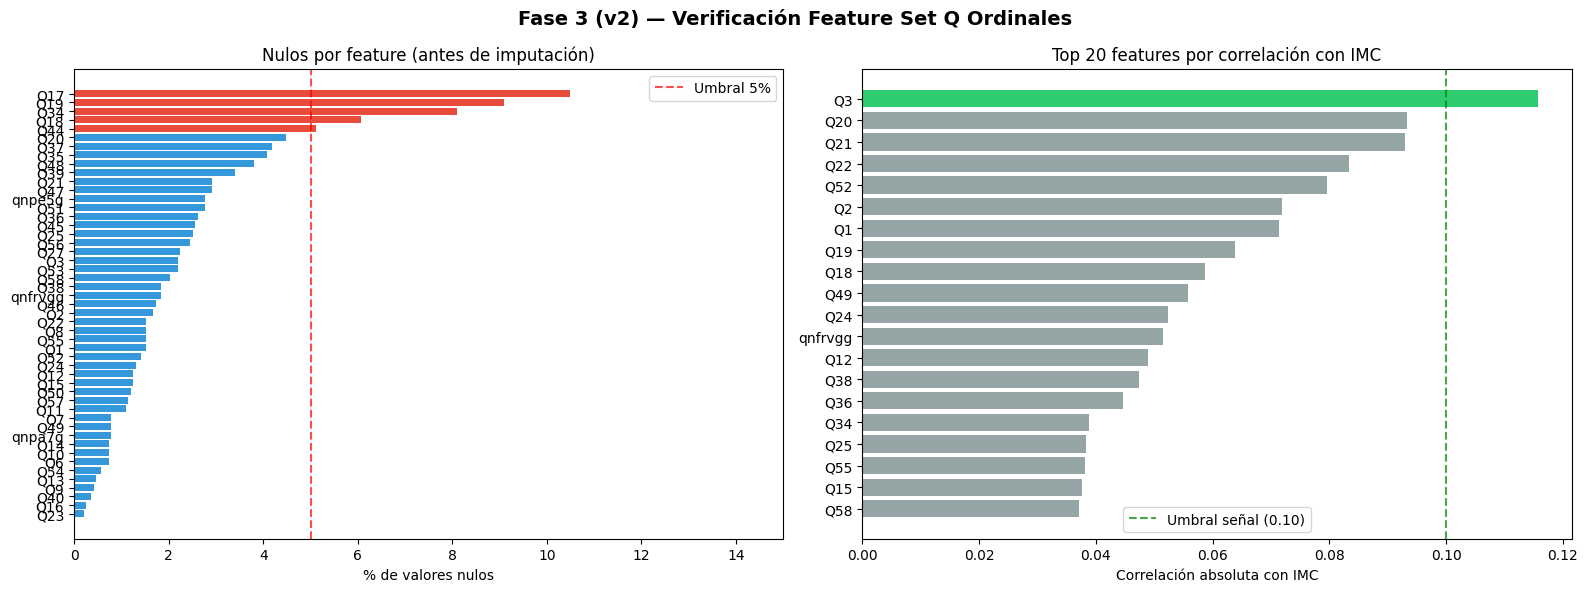

Figura guardada: 05_verificacion_features_v2.png

Top 10 features más correlacionadas con IMC:
Q3     0.1157
Q20    0.0932
Q21    0.0929
Q22    0.0834
Q52    0.0796
Q2     0.0719
Q1     0.0714
Q19    0.0639
Q18    0.0587
Q49    0.0557


In [11]:
# ── Figura de verificación del feature set ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fase 3 (v2) — Verificación Feature Set Q Ordinales',
             fontsize=14, fontweight='bold')

# ── Panel izquierdo: % nulos por feature ──────────────────
nulos_pct = (X[features_final].isnull().sum() / len(X) * 100).sort_values(ascending=True)
colores = ['#e74c3c' if v > 5 else '#3498db' for v in nulos_pct]

axes[0].barh(nulos_pct.index, nulos_pct.values, color=colores)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Umbral 5%')
axes[0].set_xlabel('% de valores nulos')
axes[0].set_title('Nulos por feature (antes de imputación)')
axes[0].legend()
axes[0].set_xlim(0, 15)

# ── Panel derecho: correlación features vs IMC ────────────
# Usamos X_train_imp (antes de escalar) para correlación
corr_imc = X_train_imp.copy()
corr_imc['IMC'] = y_A_train

correlaciones = (corr_imc.corr()['IMC']
                 .drop('IMC')
                 .abs()
                 .sort_values(ascending=False)
                 .head(20))

colores_corr = ['#2ecc71' if v > 0.1 else '#95a5a6' for v in correlaciones]

axes[1].barh(correlaciones.index[::-1],
             correlaciones.values[::-1],
             color=colores_corr[::-1])
axes[1].axvline(x=0.1, color='green', linestyle='--',
                alpha=0.7, label='Umbral señal (0.10)')
axes[1].set_xlabel('Correlación absoluta con IMC')
axes[1].set_title('Top 20 features por correlación con IMC')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / '05_verificacion_features_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: 05_verificacion_features_v2.png")

# Imprimir top 10 correlaciones
print(f"\nTop 10 features más correlacionadas con IMC:")
print(correlaciones.head(10).round(4).to_string())

## Resumen 

### Artefactos generados
| Archivo | Descripción |
|---------|-------------|
| X_train_scaled_v2.csv | 1,524 × 49 features Q ordinales escaladas |
| X_test_scaled_v2.csv  | 382 × 49 features Q ordinales escaladas |
| y_A_train_v2.csv | Target IMC train (142 NaN — se manejan en Fase 4) |
| y_A_test_v2.csv  | Target IMC test (35 NaN — se manejan en Fase 4) |
| y_B_train_v2.csv | Target Riesgo_SM train |
| y_B_test_v2.csv  | Target Riesgo_SM test |
| robust_scaler_v2.pkl | RobustScaler entrenado |

### Hallazgo clave
La correlación máxima entre features de comportamiento e IMC es 0.116 (Q3,
grado escolar). Ninguna variable de alimentación, actividad física o
comportamiento supera 0.10. Esto confirma que el GSHS 2013 fue diseñado
para medir prevalencias poblacionales, no para predecir IMC individual.
El modelo de regresión reflejará esta limitación estructural del dataset,
lo cual se documentará y justificará en el informe técnico.

### Decisión de diseño
Se procede con las 49 features.

In [13]:
# ── Resumen────────────────────────────────

print("=" * 55)
print("  FASE 3 (v2) — FEATURE ENGINEERING COMPLETADO")
print("=" * 55)

print(f"\n  Features finales : {len(features_final)}")
print(f"  Train shape      : {X_train_scaled.shape}")
print(f"  Test  shape      : {X_test_scaled.shape}")

print(f"\n  Targets Tarea A (IMC):")
print(f"    Train: {y_A_train.shape[0]} filas | NaN: {y_A_train.isnull().sum()}")
print(f"    Test : {y_A_test.shape[0]} filas  | NaN: {y_A_test.isnull().sum()}")

print(f"\n  Targets Tarea B (Riesgo_SM):")
print(f"    Train: Clase 0={int((y_B_train==0).sum())} / Clase 1={int((y_B_train==1).sum())}")
print(f"    Test : Clase 0={int((y_B_test==0).sum())}  / Clase 1={int((y_B_test==1).sum())}")

print(f"\n  Top 3 features por correlación con IMC:")
for feat, val in correlaciones.head(3).items():
    print(f"    {feat}: {val:.4f}")

print(f"\n  Señal disponible: BAJA (max corr = {correlaciones.max():.4f})")
print(f"  Estrategia Fase 4: documentar limitación del dataset")
print("=" * 55)

  FASE 3 (v2) — FEATURE ENGINEERING COMPLETADO

  Features finales : 49
  Train shape      : (1524, 49)
  Test  shape      : (382, 49)

  Targets Tarea A (IMC):
    Train: 1524 filas | NaN: 142
    Test : 382 filas  | NaN: 35

  Targets Tarea B (Riesgo_SM):
    Train: Clase 0=1320 / Clase 1=204
    Test : Clase 0=331  / Clase 1=51

  Top 3 features por correlación con IMC:
    Q3: 0.1157
    Q20: 0.0932
    Q21: 0.0929

  Señal disponible: BAJA (max corr = 0.1157)
  Estrategia Fase 4: documentar limitación del dataset
